# openLAB ENDI Pipeline (No Deep Learning)

This notebook implements the full course-project pipeline:

1) **Load openLAB acceleration trigger CSVs** and **environment CSVs**  
2) **Window** accelerations and extract interpretable features per window & sensor:
   - RMS, Std, Crest factor  
   - Welch PSD (NumPy implementation)  
   - Peak frequency proxy (0.5–20 Hz)  
   - Bandpowers in selected bands + bandpower ratios  
3) **Align** each vibration window with environment variables (T, RH, Solar)
   - `previous` (nearest earlier) or `interpolate` (linear interpolation)  
4) Train environment-to-feature models: **OLS, Ridge, Lasso, Poly+Ridge**
   - **Time-aware cross-validation** with `TimeSeriesSplit` to select alpha  
5) Compute residuals and **ENDI**:
   - `r(t) = y(t) - yhat(t)`  
   - `ENDI(t) = median_{s,k} ( |r_{s,k}(t)| / sigma_{s,k} )`  
6) Outputs: feature table, residuals+ENDI table, plots, model manifest

> **Tip:** For meaningful environmental compensation, run this across **many trigger files** spanning days/weeks so temperature/humidity/solar vary.


In [18]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from typing import List
plt.rcParams["figure.figsize"] = (10, 4)


## 0) Set paths and parameters

In [2]:
# ----------- EDIT THESE TWO PATHS ON YOUR MACHINE -----------
ACC_DIR = r"/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/01_acceleration_trigger"
ENV_DIR = r"/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/02_environment"

OUT_DIR = "openlab_project_outputs_notebook"
os.makedirs(OUT_DIR, exist_ok=True)

ACC_GLOB = "acc_*.csv"
ENV_GLOB = "environment_*.csv"

WINDOW_SECONDS = 5.0                 # 5s windows (adjust)
MAX_FILES = 0                        # 0 = all files; set e.g. 50 for quick testing
MAX_WINDOWS_PER_FILE = 0             # 0 = all windows per file
ALIGN_METHOD = "interpolate"         # "previous" or "interpolate"
POLY_DEGREE = 2                      # lightweight nonlinearity
N_SPLITS = 6                         # TimeSeriesSplit folds (auto reduced for small data)
NORMAL_FRAC = 0.6                    # early fraction treated as normal for sigma

# openLAB env column names
ENV_COL_MAP = {
    "temp": "G_HTST_ENVR_EN0000_0",
    "rh":   "G_HTSH_ENVR_EN0000_0",
    "solar":"G_PYRS_ENVR_EN0000_0",
}

BANDS = [(0.5,2.0),(2.0,5.0),(5.0,10.0),(10.0,20.0)]
PEAK_BAND = (0.5, 20.0)


## 1) Helpers: timestamps, Welch PSD, bandpower, feature extraction

In [3]:
def estimate_fs_from_timestamp(ts: pd.Series) -> float:
    dt = ts.diff().dt.total_seconds().dropna()
    if len(dt) == 0:
        return float("nan")
    med = float(dt.median())
    return 1.0/med if med > 0 else float("nan")

def welch_psd_numpy(x: np.ndarray, fs: float, nperseg: int = 2048, noverlap: int = 1024):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n < 128:
        win = np.hanning(max(n, 2))
        x0 = x - np.mean(x) if n > 0 else x
        X = np.fft.rfft(x0 * win[:n])
        psd = (np.abs(X)**2) / (fs * np.sum(win[:n]**2))
        freqs = np.fft.rfftfreq(n, d=1/fs) if n > 0 else np.array([0.0])
        return freqs, psd

    if n < nperseg:
        nperseg = 2**int(np.floor(np.log2(n)))
        nperseg = max(nperseg, 128)
        noverlap = nperseg // 2

    step = nperseg - noverlap
    win = np.hanning(nperseg)
    scale = fs * np.sum(win**2)

    psds = []
    for start in range(0, n - nperseg + 1, step):
        seg = x[start:start+nperseg]
        seg = seg - np.mean(seg)
        X = np.fft.rfft(seg * win)
        psds.append((np.abs(X)**2) / scale)

    if len(psds) == 0:
        win = np.hanning(n)
        x0 = x - np.mean(x)
        X = np.fft.rfft(x0 * win)
        psd = (np.abs(X)**2) / (fs * np.sum(win**2))
        freqs = np.fft.rfftfreq(n, d=1/fs)
        return freqs, psd

    psd = np.mean(psds, axis=0)
    freqs = np.fft.rfftfreq(nperseg, d=1/fs)
    return freqs, psd

def bandpower(freqs: np.ndarray, psd: np.ndarray, f1: float, f2: float) -> float:
    mask = (freqs >= f1) & (freqs < f2)
    if not np.any(mask):
        return np.nan
    return float(np.trapz(psd[mask], freqs[mask]))

def extract_features_for_window(window_df: pd.DataFrame, acc_cols, fs: float, bands=BANDS, peak_band=PEAK_BAND):
    feats = {}
    for ch in acc_cols:
        x = window_df[ch].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            continue

        x = x - np.mean(x)
        rms = float(np.sqrt(np.mean(x**2)))
        std = float(np.std(x))
        crest = float(np.max(np.abs(x)) / (rms + 1e-12))

        freqs, psd = welch_psd_numpy(x, fs=fs)
        f_lo, f_hi = peak_band
        pmask = (freqs >= f_lo) & (freqs <= f_hi)
        pk = float(freqs[pmask][np.argmax(psd[pmask])]) if np.any(pmask) else float(freqs[np.argmax(psd)])

        feats[f"{ch}_rms"] = rms
        feats[f"{ch}_std"] = std
        feats[f"{ch}_crest"] = crest
        feats[f"{ch}_peakHz"] = pk

        for (b1, b2) in bands:
            feats[f"{ch}_bp_{b1:g}_{b2:g}"] = bandpower(freqs, psd, b1, b2)

        # example ratio: 2–5 / 0.5–2
        bp_hi = feats.get(f"{ch}_bp_2_5", np.nan)
        bp_lo = feats.get(f"{ch}_bp_0.5_2", np.nan)
        if np.isfinite(bp_hi) and np.isfinite(bp_lo):
            feats[f"{ch}_bpr_2_5_over_0.5_2"] = float(bp_hi / (bp_lo + 1e-12))

    return feats


## 2) Load all environment CSVs (Feb–Oct)

In [4]:
env_files = sorted(glob.glob(os.path.join(ENV_DIR, ENV_GLOB)))
print("Env files:", len(env_files))
env_files[:3]


Env files: 9


['/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/02_environment/environment_2024_02.csv',
 '/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/02_environment/environment_2024_03.csv',
 '/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/02_environment/environment_2024_04.csv']

In [5]:
dfs = []
for f in env_files:
    e = pd.read_csv(f)
    if "Timestamp" not in e.columns:
        continue
    e["Timestamp"] = pd.to_datetime(e["Timestamp"])
    e["env_file"] = os.path.basename(f)
    dfs.append(e)

env = pd.concat(dfs, ignore_index=True).sort_values("Timestamp").reset_index(drop=True)
env.head()


,Timestamp,G_HTST_ENVR_EN0000_0,G_HTSH_ENVR_EN0000_0,G_PYRS_ENVR_EN0000_0,env_file
0,2024-02-01 00:00:00,0.795248,88.181015,-0.004506,environment_2024_02.csv
1,2024-02-01 00:10:00,0.779205,88.634796,-0.008112,environment_2024_02.csv
2,2024-02-01 00:20:00,0.792473,88.098854,-0.002343,environment_2024_02.csv
3,2024-02-01 00:30:00,0.584578,89.190994,0.007571,environment_2024_02.csv
4,2024-02-01 00:40:00,0.420481,89.631104,-0.004506,environment_2024_02.csv


## 3) Extract features from many trigger files (windowed feature table)

In [6]:
acc_files = sorted(glob.glob(os.path.join(ACC_DIR, ACC_GLOB)))
if MAX_FILES and MAX_FILES > 0:
    acc_files = acc_files[:MAX_FILES]

print("Acc files:", len(acc_files))
acc_files[:3]


Acc files: 526


['/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/01_acceleration_trigger/acc_2024_05_02_T06_16_01.csv',
 '/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/01_acceleration_trigger/acc_2024_05_02_T06_17_17.csv',
 '/Users/ronitbaishya/Desktop/Lehigh University/Research/2nd Semester/2024-02-01_2024-10-31_ida_ki_export/01_acceleration_trigger/acc_2024_05_02_T07_41_28.csv']

In [7]:
all_feat = []
skipped = 0

for f in acc_files:
    acc = pd.read_csv(f)
    if "Timestamp" not in acc.columns:
        skipped += 1
        continue

    acc["Timestamp"] = pd.to_datetime(acc["Timestamp"])
    all_acc_cols = [c for c in acc.columns if c != "Timestamp"]
    acc_cols = [c for c in all_acc_cols if not acc[c].isna().all()]
    fs = estimate_fs_from_timestamp(acc["Timestamp"])
    if not np.isfinite(fs):
        skipped += 1
        continue

    win_n = int(round(WINDOW_SECONDS * fs))
    if win_n < 64:
        skipped += 1
        continue

    starts = list(range(0, len(acc) - win_n + 1, win_n))
    if MAX_WINDOWS_PER_FILE and MAX_WINDOWS_PER_FILE > 0:
        starts = starts[:MAX_WINDOWS_PER_FILE]

    rows = []
    for st in starts:
        w = acc.iloc[st:st+win_n]
        feats = extract_features_for_window(w, acc_cols=acc_cols, fs=fs, bands=BANDS, peak_band=PEAK_BAND)
        if len(feats) == 0:
            continue
        feats["timestamp"] = w["Timestamp"].iloc[0]
        feats["acc_file"] = os.path.basename(f)
        feats["fs_estimated_hz"] = fs
        feats["window_seconds"] = WINDOW_SECONDS
        rows.append(feats)

    if len(rows) > 0:
        all_feat.append(pd.DataFrame(rows))

feat = pd.concat(all_feat, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
print("Feature rows:", len(feat), "| skipped files:", skipped)
feat.head()


/var/folders/b7/xqmthnf914b9gkv5kh0gfbqw0000gn/T/ipykernel_97217/2119923434.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/b7/xqmthnf914b9gkv5kh0gfbqw0000gn/T/ipykernel_97217/2119923434.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/b7/xqmthnf914b9gkv5kh0gfbqw0000gn/T/ipykernel_97217/2119923434.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))
/var/folders/b7/xqmthnf914b9gkv5kh0gfbqw0000gn/T/ipykernel_97217/2119923434.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions

Feature rows: 7363 | skipped files: 0


/var/folders/b7/xqmthnf914b9gkv5kh0gfbqw0000gn/T/ipykernel_97217/2119923434.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[mask], freqs[mask]))


,G_ACCZ_PE11_CB0750_0_rms,G_ACCZ_PE11_CB0750_0_std,G_ACCZ_PE11_CB0750_0_crest,G_ACCZ_PE11_CB0750_0_peakHz,G_ACCZ_PE11_CB0750_0_bp_0.5_2,G_ACCZ_PE11_CB0750_0_bp_2_5,G_ACCZ_PE11_CB0750_0_bp_5_10,G_ACCZ_PE11_CB0750_0_bp_10_20,G_ACCZ_PE11_CB0750_0_bpr_2_5_over_0.5_2,G_ACCZ_PE12_CB0750_0_rms,...,window_seconds,G_ACCZ_PE21_CB0750_0_rms,G_ACCZ_PE21_CB0750_0_std,G_ACCZ_PE21_CB0750_0_crest,G_ACCZ_PE21_CB0750_0_peakHz,G_ACCZ_PE21_CB0750_0_bp_0.5_2,G_ACCZ_PE21_CB0750_0_bp_2_5,G_ACCZ_PE21_CB0750_0_bp_5_10,G_ACCZ_PE21_CB0750_0_bp_10_20,G_ACCZ_PE21_CB0750_0_bpr_2_5_over_0.5_2
0,0.000002,0.000002,6.520453,0.732422,1.823028e-13,8.424827e-14,1.598076e-13,2.301371e-13,0.071258,0.000002,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000004,0.000004,18.361049,10.742188,2.591063e-14,8.551939e-14,7.680075e-14,1.695481e-13,0.083359,0.000004,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000006,0.000006,9.424545,10.498047,1.231977e-13,8.982316e-14,2.683445e-13,1.783293e-12,0.079971,0.000005,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000002,0.000002,4.292432,7.080078,1.245545e-13,1.085683e-13,1.084397e-13,1.370080e-13,0.096543,0.000002,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000007,0.000007,16.734661,10.009766,1.858317e-13,1.488795e-13,4.137283e-13,6.516490e-13,0.125549,0.000005,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Align environment (previous vs interpolate)

In [8]:
needed = ["Timestamp"] + list(ENV_COL_MAP.values())
for c in needed:
    if c not in env.columns:
        raise ValueError(f"Missing env column: {c}")

feat2 = feat.copy().sort_values("timestamp").reset_index(drop=True)
env_sorted = env.sort_values("Timestamp").reset_index(drop=True)

if ALIGN_METHOD == "previous":
    merged = pd.merge_asof(feat2, env_sorted, left_on="timestamp", right_on="Timestamp",
                           direction="backward", suffixes=("", "_env"))
    for new_name, old_name in ENV_COL_MAP.items():
        merged[new_name] = merged[old_name]
    feat2 = merged

elif ALIGN_METHOD == "interpolate":
    prev = pd.merge_asof(feat2[["timestamp"]], env_sorted[["Timestamp"] + list(ENV_COL_MAP.values())],
                         left_on="timestamp", right_on="Timestamp", direction="backward").rename(columns={"Timestamp":"prev_ts"})
    nxt = pd.merge_asof(feat2[["timestamp"]], env_sorted[["Timestamp"] + list(ENV_COL_MAP.values())],
                        left_on="timestamp", right_on="Timestamp", direction="forward").rename(columns={"Timestamp":"next_ts"})
    feat2["prev_ts"] = prev["prev_ts"]
    feat2["next_ts"] = nxt["next_ts"]

    t  = feat2["timestamp"].astype("int64") / 1e9
    t0 = feat2["prev_ts"].astype("int64") / 1e9
    t1 = feat2["next_ts"].astype("int64") / 1e9
    w = ((t - t0) / (t1 - t0)).clip(0, 1)

    for new_name, old_name in ENV_COL_MAP.items():
        v0 = prev[old_name].astype(float)
        v1 = nxt[old_name].astype(float)
        feat2[new_name] = (1 - w) * v0 + w * v1
else:
    raise ValueError("ALIGN_METHOD must be 'previous' or 'interpolate'")

# Keep only rows with env
x_cols = ["temp", "rh", "solar"]
feat2 = feat2.replace([np.inf, -np.inf], np.nan).dropna(subset=x_cols).reset_index(drop=True)

feat2[["timestamp"] + x_cols].head()


,timestamp,temp,rh,solar
0,2024-05-02 06:16:01.162,18.483524,45.327534,417.933809
1,2024-05-02 06:16:06.162,18.485408,45.326286,421.669776
2,2024-05-02 06:16:11.162,18.487291,45.325038,425.405743
3,2024-05-02 06:16:16.162,18.489174,45.323790,429.141709
4,2024-05-02 06:16:21.162,18.491058,45.322542,432.877676


## 5) Select target features y(t)

In [9]:
y_cols = [c for c in feat2.columns if c.endswith("_peakHz") or c.endswith("_bpr_2_5_over_0.5_2")]
print("Number of y features:", len(y_cols))
y_cols[:10]


Number of y features: 12


['G_ACCZ_PE11_CB0750_0_peakHz',
 'G_ACCZ_PE11_CB0750_0_bpr_2_5_over_0.5_2',
 'G_ACCZ_PE12_CB0750_0_peakHz',
 'G_ACCZ_PE12_CB0750_0_bpr_2_5_over_0.5_2',
 'G_ACCZ_PE13_CB0750_0_peakHz',
 'G_ACCZ_PE13_CB0750_0_bpr_2_5_over_0.5_2',
 'G_ACCZ_PE22_CB0750_0_peakHz',
 'G_ACCZ_PE22_CB0750_0_bpr_2_5_over_0.5_2',
 'G_ACCZ_PE23_CB0750_0_peakHz',
 'G_ACCZ_PE23_CB0750_0_bpr_2_5_over_0.5_2']

## 6) Model selection per feature (OLS, Ridge, Lasso, Poly+Ridge) with TimeSeriesSplit

In [10]:
def time_series_cv_mse(pipe: Pipeline, X: np.ndarray, y: np.ndarray, n_splits: int = 6) -> float:
    n_splits = min(n_splits, max(2, len(y)//5))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mses = []
    for tr, te in tscv.split(X):
        pipe.fit(X[tr], y[tr])
        pred = pipe.predict(X[te])
        mses.append(mean_squared_error(y[te], pred))
    return float(np.mean(mses))

def select_alpha_time_cv(X, y, model_kind="ridge", poly_degree=None, alphas=None, n_splits=6):
    if alphas is None:
        alphas = np.logspace(-4, 2, 18)
    n_splits = min(n_splits, max(2, len(y)//5))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_mse = []

    for a in alphas:
        steps = [("scaler", StandardScaler())]
        if poly_degree is not None:
            steps.append(("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)))
        if model_kind == "ridge":
            steps.append(("model", Ridge(alpha=float(a))))
        elif model_kind == "lasso":
            steps.append(("model", Lasso(alpha=float(a), max_iter=20000)))
        else:
            raise ValueError("model_kind must be ridge or lasso")

        pipe = Pipeline(steps)

        mses = []
        for tr, te in tscv.split(X):
            pipe.fit(X[tr], y[tr])
            pred = pipe.predict(X[te])
            mses.append(mean_squared_error(y[te], pred))
        cv_mse.append(float(np.mean(mses)))

    cv_mse = np.array(cv_mse)
    best_idx = int(np.argmin(cv_mse))
    return float(alphas[best_idx]), np.array(alphas), cv_mse

def fit_and_choose_model_for_feature(X, y, poly_degree=2, n_splits=6):
    models = {}

    ols = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    models["ols"] = {"pipe": ols, "cv_mse": time_series_cv_mse(ols, X, y, n_splits=n_splits), "alpha": None}

    a_r, alphas_r, curve_r = select_alpha_time_cv(X, y, "ridge", None, None, n_splits=n_splits)
    ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=a_r))])
    models["ridge"] = {"pipe": ridge, "cv_mse": float(curve_r.min()), "alpha": a_r, "alphas": alphas_r, "curve": curve_r}

    a_l, alphas_l, curve_l = select_alpha_time_cv(X, y, "lasso", None, None, n_splits=n_splits)
    lasso = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=a_l, max_iter=20000))])
    models["lasso"] = {"pipe": lasso, "cv_mse": float(curve_l.min()), "alpha": a_l, "alphas": alphas_l, "curve": curve_l}

    a_pr, alphas_pr, curve_pr = select_alpha_time_cv(X, y, "ridge", poly_degree, None, n_splits=n_splits)
    poly_ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ("model", Ridge(alpha=a_pr))
    ])
    models["poly_ridge"] = {"pipe": poly_ridge, "cv_mse": float(curve_pr.min()), "alpha": a_pr, "degree": poly_degree,
                            "alphas": alphas_pr, "curve": curve_pr}

    order = sorted(models.items(), key=lambda kv: (kv[1]["cv_mse"], 0 if kv[0] in ("ridge","ols") else 1))
    best_name, best = order[0]

    # Fit best on all data
    best["pipe"].fit(X, y)

    return best_name, best, models


In [14]:
X_all = feat2[x_cols].to_numpy(dtype=float)

residuals = pd.DataFrame({"timestamp": feat2["timestamp"], "acc_file": feat2["acc_file"]})
model_manifest = {}

for ycol in y_cols:
    y = feat2[ycol].to_numpy(dtype=float)
    mask = np.isfinite(y) & np.all(np.isfinite(X_all), axis=1)
    if mask.sum() < 30:
        continue

    X = X_all[mask]
    yy = y[mask]

    best_name, best, models = fit_and_choose_model_for_feature(X, yy, poly_degree=POLY_DEGREE, n_splits=N_SPLITS)

    yhat = np.full(len(y), np.nan)
    yhat[mask] = best["pipe"].predict(X)
    r = y - yhat

    residuals[ycol] = y
    residuals[ycol + "_yhat"] = yhat
    residuals[ycol + "_r"] = r

    model_manifest[ycol] = {
        "best_model": best_name,
        "best_cv_mse": float(best["cv_mse"]),
        "best_alpha": best.get("alpha", None),
        "best_degree": best.get("degree", None),
        "cv_mse_all": {k: float(v["cv_mse"]) for k, v in models.items()}
    }

print("Modeled features:", len(model_manifest))
residuals.shape


Modeled features: 12


(7363, 38)

## 7) Compute ENDI

In [19]:
res_cols = [c for c in residuals.columns if c.endswith("_r")]
residuals = residuals.replace([np.inf, -np.inf], np.nan).dropna(subset=res_cols, how="all").reset_index(drop=True)

def compute_ENDI(df: pd.DataFrame, res_cols: List[str], normal_frac: float = 0.6):
    n = len(df)
    n0 = max(10, int(n * normal_frac))
    normal_mask = np.arange(n) < n0

    Z = []
    for c in res_cols:
        r = df[c].to_numpy(dtype=float)
        sigma = np.std(r[normal_mask])
        sigma = sigma if sigma > 1e-12 else 1.0
        Z.append(np.abs(r) / sigma)

    Z = np.vstack(Z).T
    return np.median(Z, axis=1)

residuals["ENDI"] = compute_ENDI(residuals, res_cols, normal_frac=NORMAL_FRAC)
residuals[["timestamp","ENDI"]].head()


,timestamp,ENDI
0,2024-05-02 06:16:01.162,NaN
1,2024-05-02 06:16:06.162,NaN
2,2024-05-02 06:16:11.162,NaN
3,2024-05-02 06:16:16.162,NaN
4,2024-05-02 06:16:21.162,NaN


## 8) Save tables + manifest

In [20]:
feat2.to_csv(os.path.join(OUT_DIR, "windowed_feature_table_with_env.csv"), index=False)
residuals.to_csv(os.path.join(OUT_DIR, "residuals_and_ENDI.csv"), index=False)

with open(os.path.join(OUT_DIR, "model_manifest.json"), "w") as f:
    json.dump(model_manifest, f, indent=2)

print("Saved outputs to:", OUT_DIR)


Saved outputs to: openlab_project_outputs_notebook


## 9) Plots

In [21]:
rep = None
for c in y_cols:
    if c in residuals.columns:
        rep = c
        break
rep


'G_ACCZ_PE11_CB0750_0_peakHz'

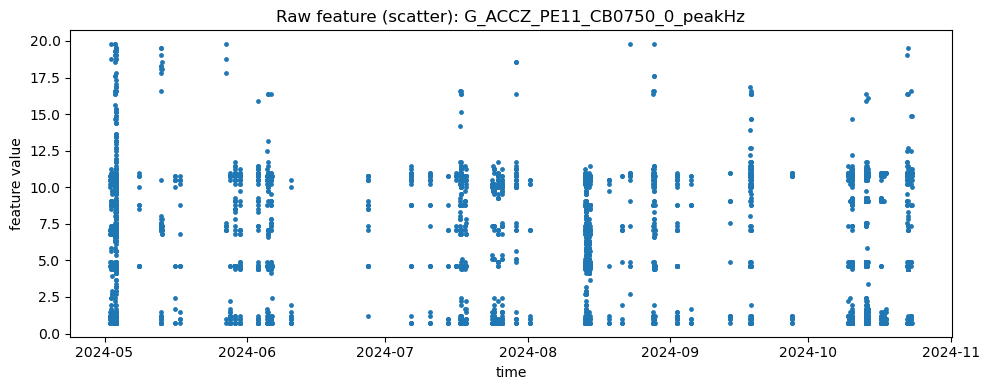

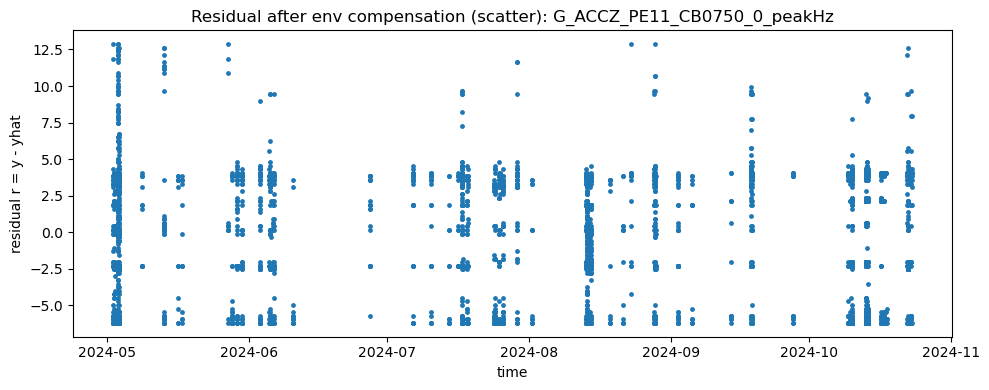

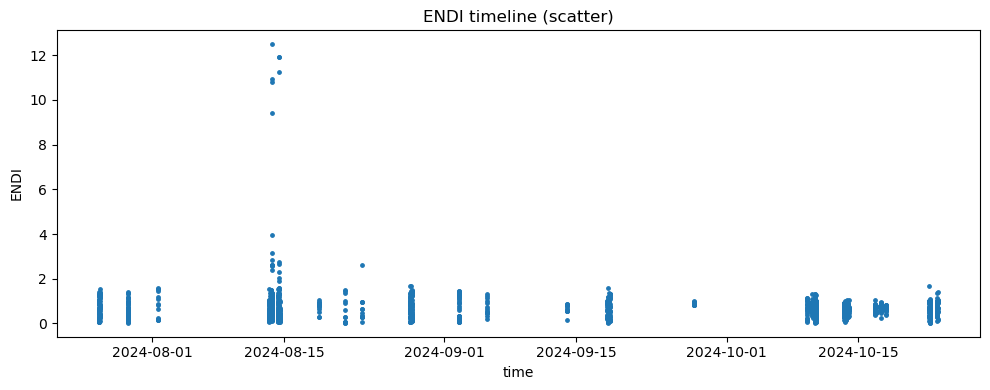

In [28]:
# Raw drift
plt.figure()
plt.scatter(feat2["timestamp"], feat2[rep], s=6)   # s = marker size
plt.title(f"Raw feature (scatter): {rep}")
plt.xlabel("time")
plt.ylabel("feature value")
plt.tight_layout()
plt.show()

# Residual drift
plt.figure()
plt.scatter(residuals["timestamp"], residuals[rep + "_r"], s=6)
plt.title(f"Residual after env compensation (scatter): {rep}")
plt.xlabel("time")
plt.ylabel("residual r = y - yhat")
plt.tight_layout()
plt.show()

# ENDI
plt.figure()
plt.scatter(residuals["timestamp"], residuals["ENDI"], s=6)
plt.title("ENDI timeline (scatter)")
plt.xlabel("time")
plt.ylabel("ENDI")
plt.tight_layout()
plt.show()


## 10) CV curves (representative feature)

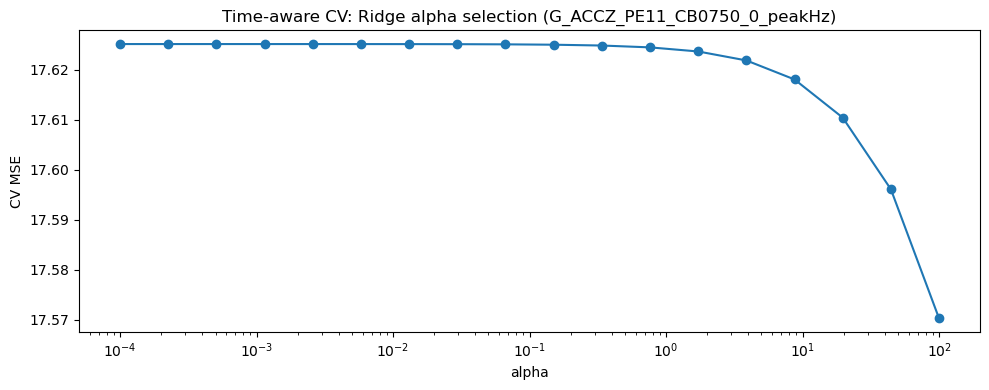

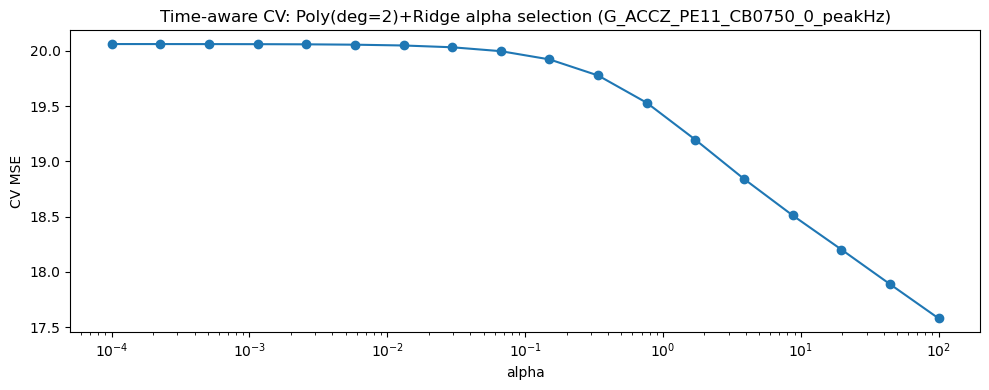

In [23]:
# CV curves for representative feature
y = feat2[rep].to_numpy(dtype=float)
mask = np.isfinite(y) & np.all(np.isfinite(X_all), axis=1)
X = X_all[mask]
yy = y[mask]

a_r, alphas_r, curve_r = select_alpha_time_cv(X, yy, "ridge", None, None, n_splits=N_SPLITS)
plt.figure()
plt.semilogx(alphas_r, curve_r, marker="o")
plt.title(f"Time-aware CV: Ridge alpha selection ({rep})")
plt.xlabel("alpha"); plt.ylabel("CV MSE")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cv_ridge.png"), dpi=220)
plt.show()

a_pr, alphas_pr, curve_pr = select_alpha_time_cv(X, yy, "ridge", POLY_DEGREE, None, n_splits=N_SPLITS)
plt.figure()
plt.semilogx(alphas_pr, curve_pr, marker="o")
plt.title(f"Time-aware CV: Poly(deg={POLY_DEGREE})+Ridge alpha selection ({rep})")
plt.xlabel("alpha"); plt.ylabel("CV MSE")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cv_poly_ridge.png"), dpi=220)
plt.show()


## 11) (Optional) Block bootstrap CI for variance reduction

In [24]:
def block_bootstrap_variance_reduction(y_raw, y_res, block_size, n_boot=300, seed=7):
    rng = np.random.default_rng(seed)
    n = len(y_raw)
    starts = np.arange(0, n, block_size)
    blocks = [(s, min(s+block_size, n)) for s in starts]
    nb = len(blocks)

    deltas = []
    for _ in range(n_boot):
        idx = []
        picks = rng.integers(0, nb, size=nb)
        for p in picks:
            a, b = blocks[p]
            idx.extend(range(a, b))
        idx = np.array(idx, dtype=int)
        deltas.append(np.var(y_raw[idx]) - np.var(y_res[idx]))

    deltas = np.array(deltas)
    return {
        "delta_mean": float(np.mean(deltas)),
        "ci_low": float(np.quantile(deltas, 0.025)),
        "ci_high": float(np.quantile(deltas, 0.975))
    }

y_raw = residuals[rep].to_numpy(dtype=float)
y_res = residuals[rep + "_r"].to_numpy(dtype=float)
block_size = min(10, max(5, len(y_raw)//5))  # heuristic

boot = block_bootstrap_variance_reduction(y_raw, y_res, block_size=block_size, n_boot=300)
boot


{'delta_mean': 2.0132044179869504e-16,
 'ci_low': -3.552713678800501e-15,
 'ci_high': 3.552713678800501e-15}